In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import copy
import time
import matplotlib.pyplot as plt
import numpy as np

# 封装随机种子函数
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

# 设置设备
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"当前运行设备: {DEVICE}")
set_seed(42)

# 数据路径 (根据实际情况修改)
DATA_ROOT = './cardata'

当前运行设备: cuda


In [2]:
class VehicleDataset(Dataset):
    def __init__(self, img_paths, labels, transform=None, flatten=False):
        self.img_paths = img_paths
        self.labels = labels
        self.transform = transform
        self.flatten = flatten # 新增参数：是否展平图像
        
    def __len__(self): return len(self.img_paths)
    
    def __getitem__(self, idx):
        try:
            image = Image.open(self.img_paths[idx]).convert('RGB')
            if self.transform: 
                image = self.transform(image)
            
            # 如果是 FNN，需要展平: (C, H, W) -> (C*H*W)
            if self.flatten:
                image = image.view(-1)
                
            return image, self.labels[idx]
        except Exception as e:
            # 异常处理：返回全零张量
            print(f"Error loading image {self.img_paths[idx]}: {e}")
            # 根据是否展平返回不同形状的零张量 (假设 resize 为 64x64)
            if self.flatten:
                return torch.zeros(3*64*64), self.labels[idx]
            else:
                return torch.zeros(3, 64, 64), self.labels[idx]

def get_data_loaders(data_root, batch_size=32, target_size=(64, 64), flatten=False):
    """
    通用数据加载函数
    :param flatten: True for FNN, False for CNN
    """
    valid_ext = ('.jpg', '.png', '.jpeg')
    
    # 定义 Transform (统一 Resize 到 64x64)
    train_transform = transforms.Compose([
        transforms.Resize(target_size),
        transforms.RandomHorizontalFlip(), # 数据增强
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])
    
    test_transform = transforms.Compose([
        transforms.Resize(target_size),
        transforms.ToTensor(),
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])
    
    # 路径获取 (复用之前的逻辑)
    classes = ['bus', 'car', 'truck']
    class_map = {n: i for i, n in enumerate(classes)}
    train_paths, train_lbls, test_paths, test_lbls = [], [], [], []
    
    for cls in classes:
        cls_dir = os.path.join(data_root, cls)
        if not os.path.exists(cls_dir): continue
        imgs = [os.path.join(cls_dir, x) for x in os.listdir(cls_dir) if x.lower().endswith(valid_ext)]
        np.random.shuffle(imgs)
        split = int(len(imgs) * 0.2)
        
        test_paths.extend(imgs[:split]); test_lbls.extend([class_map[cls]]*len(imgs[:split]))
        train_paths.extend(imgs[split:]); train_lbls.extend([class_map[cls]]*len(imgs[split:]))
    
    # 实例化 Dataset
    train_ds = VehicleDataset(train_paths, train_lbls, train_transform, flatten=flatten)
    test_ds = VehicleDataset(test_paths, test_lbls, test_transform, flatten=flatten)
    
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_ds, batch_size=batch_size, shuffle=False)
    
    input_dim = 3 * target_size[0] * target_size[1] # 计算输入维度
    
    return train_loader, test_loader, input_dim

In [3]:
# --- FNN 模型 ---
class FeedForwardNet(nn.Module):
    def __init__(self, input_dim, hidden_dims=[512, 256], output_dim=3, dropout_rate=0.5):
        super(FeedForwardNet, self).__init__()
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim
            
        layers.append(nn.Linear(prev_dim, output_dim))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

# --- Shallow CNN 模型 ---
class ShallowCNN(nn.Module):
    def __init__(self, num_classes=3):
        super(ShallowCNN, self).__init__()
        self.features = nn.Sequential(
            # Input: 3x64x64
            nn.Conv2d(3, 16, kernel_size=3, padding=1), # -> 16x64x64
            nn.ReLU(),
            nn.MaxPool2d(2), # -> 16x32x32
            
            nn.Conv2d(16, 32, kernel_size=3, padding=1), # -> 32x32x32
            nn.ReLU(),
            nn.MaxPool2d(2)  # -> 32x16x16
        )
        
        # 展平后维度: 32 * 16 * 16 = 8192
        self.classifier = nn.Sequential(
            nn.Linear(32 * 16 * 16, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1) # Flatten
        x = self.classifier(x)
        return x

In [ ]:
def train_network(model, train_loader, test_loader, lr=0.001, epochs=30, patience=5, device=DEVICE, name="Model"):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # 记录关键指标
    history = {'loss': [], 'test_acc': [], 'time': [], 'name': name}
    
    best_loss = float('inf')
    patience_counter = 0
    best_model_wts = copy.deepcopy(model.state_dict())
    
    print(f"开始训练 {name}...")
    
    for epoch in range(epochs):
        ep_start = time.time()
        
        # 训练
        model.train()
        running_loss = 0.0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, lbls)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
            
        # 验证
        model.eval()
        test_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for imgs, lbls in test_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                outputs = model(imgs)
                loss = criterion(outputs, lbls)
                test_loss += loss.item()
                _, preds = torch.max(outputs, 1)
                total += lbls.size(0)
                correct += (preds == lbls).sum().item()
        
        # 记录数据
        avg_train_loss = running_loss / len(train_loader)
        avg_test_loss = test_loss / len(test_loader)
        test_acc = 100 * correct / total
        ep_time = time.time() - ep_start
        
        history['loss'].append(avg_train_loss)
        history['test_acc'].append(test_acc)
        history['time'].append(ep_time)
        
        print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f} | Acc: {test_acc:.2f}% | Time: {ep_time:.1f}s")
        
        # 早停检查
        if avg_test_loss < best_loss:
            best_loss = avg_test_loss
            patience_counter = 0
            best_model_wts = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break
                
    model.load_state_dict(best_model_wts)
    return history

import numpy as np
import matplotlib.pyplot as plt


def plot_comparison(results_list):
    """
    绘制 FNN 与 CNN 的全方位对比图。
    参数 results_list 必须是一个列表，例如 [fnn_hist, cnn_hist]
    """
    plt.figure(figsize=(15, 10))
    
    # 颜色配置
    colors = ['orange', 'skyblue', 'lightgreen', 'pink']
    
    # 1. 准确率对比
    plt.subplot(2, 2, 1)
    for i, res in enumerate(results_list):
        plt.plot(res['test_acc'], label=res['name'], marker='.', linestyle='--', color=colors[i % len(colors)])
    plt.title('Test Accuracy Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 2. Loss 对比
    plt.subplot(2, 2, 2)
    for i, res in enumerate(results_list):
        plt.plot(res['loss'], label=f"{res['name']} Train Loss", marker='.', linestyle='-', color=colors[i % len(colors)])
    plt.title('Training Loss Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 3. 总耗时对比
    plt.subplot(2, 2, 3)
    names = [res['name'] for res in results_list]
    times = [sum(res['time']) for res in results_list]
    bars = plt.bar(names, times, color=colors[:len(results_list)])
    plt.title('Total Training Time')
    plt.ylabel('Seconds')
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height, f'{height:.1f}s', ha='center', va='bottom')
    
    # 4. 每轮耗时对比 (分组柱状图 - 完整保留逻辑)
    plt.subplot(2, 2, 4)
    
    total_width = 0.8          
    n_exp = len(results_list) 
    bar_width = total_width / n_exp 
    
    for i, res in enumerate(results_list):
        epoch_times = res['time']
        # 核心逻辑：生成偏移后的X轴坐标
        # 基础坐标 1,2,3... 加上偏移量
        x_positions = np.arange(1, len(epoch_times) + 1) - (total_width / 2) + (i * bar_width) + (bar_width / 2)
        
        plt.bar(x_positions, epoch_times, width=bar_width, label=res['name'], color=colors[i % len(colors)], alpha=0.7)

    plt.title('Time per Epoch Comparison')
    plt.xlabel('Epoch')
    plt.ylabel('Seconds')
    plt.legend()
    plt.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.show()

In [ ]:
import gc # 引入垃圾回收模块

def clear_gpu_memory():
    """强制清理 GPU 缓存"""
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()
    gc.collect()

BATCH_SIZE = 32
LR = 0.001
EPOCHS = 50
PATIENCE = 5

print("="*30)
print(">>> 1. 正在准备 FNN 数据与模型...")
print("="*30)

fnn_train_loader, fnn_test_loader, input_dim = get_data_loaders(DATA_ROOT, batch_size=BATCH_SIZE, flatten=True)

fnn_model = FeedForwardNet(input_dim=input_dim, hidden_dims=[512, 256], output_dim=3)

fnn_history = train_network(fnn_model, fnn_train_loader, fnn_test_loader, lr=LR, epochs=EPOCHS, patience=PATIENCE, name="FNN")


del fnn_model
del fnn_train_loader
del fnn_test_loader

# 2. 执行清理
clear_gpu_memory()

print("\n" + "="*30)
print(">>> 2. 正在准备 CNN 数据与模型...")
print("="*30)

cnn_train_loader, cnn_test_loader, _ = get_data_loaders(DATA_ROOT, batch_size=BATCH_SIZE, flatten=False)

cnn_model = ShallowCNN(num_classes=3)
cnn_history = train_network(cnn_model, cnn_train_loader, cnn_test_loader, lr=LR, epochs=EPOCHS, patience=PATIENCE, name="CNN")


>>> 1. 正在准备 FNN 数据与模型...
开始训练 FNN...
Epoch [1/50] Loss: 0.8360 | Test Loss: 0.5084 | Acc: 80.74% | Time: 4.0s
Epoch [2/50] Loss: 0.5316 | Test Loss: 0.3371 | Acc: 85.93% | Time: 3.1s
Epoch [3/50] Loss: 0.3617 | Test Loss: 0.3585 | Acc: 84.81% | Time: 2.9s
Epoch [4/50] Loss: 0.3354 | Test Loss: 0.2709 | Acc: 89.63% | Time: 3.0s
Epoch [5/50] Loss: 0.3111 | Test Loss: 0.2532 | Acc: 90.74% | Time: 3.0s
Epoch [6/50] Loss: 0.2687 | Test Loss: 0.2447 | Acc: 90.00% | Time: 3.0s
Epoch [7/50] Loss: 0.2767 | Test Loss: 0.2474 | Acc: 91.11% | Time: 3.0s
Epoch [8/50] Loss: 0.2158 | Test Loss: 0.2249 | Acc: 92.59% | Time: 2.9s
Epoch [9/50] Loss: 0.2428 | Test Loss: 0.2061 | Acc: 90.00% | Time: 2.7s
Epoch [10/50] Loss: 0.2142 | Test Loss: 0.3157 | Acc: 87.78% | Time: 3.0s
Epoch [11/50] Loss: 0.1882 | Test Loss: 0.2649 | Acc: 90.74% | Time: 2.9s
Epoch [12/50] Loss: 0.1772 | Test Loss: 0.2413 | Acc: 91.85% | Time: 2.8s
Epoch [13/50] Loss: 0.1597 | Test Loss: 0.1995 | Acc: 93.33% | Time: 2.8s
Epoch [14/

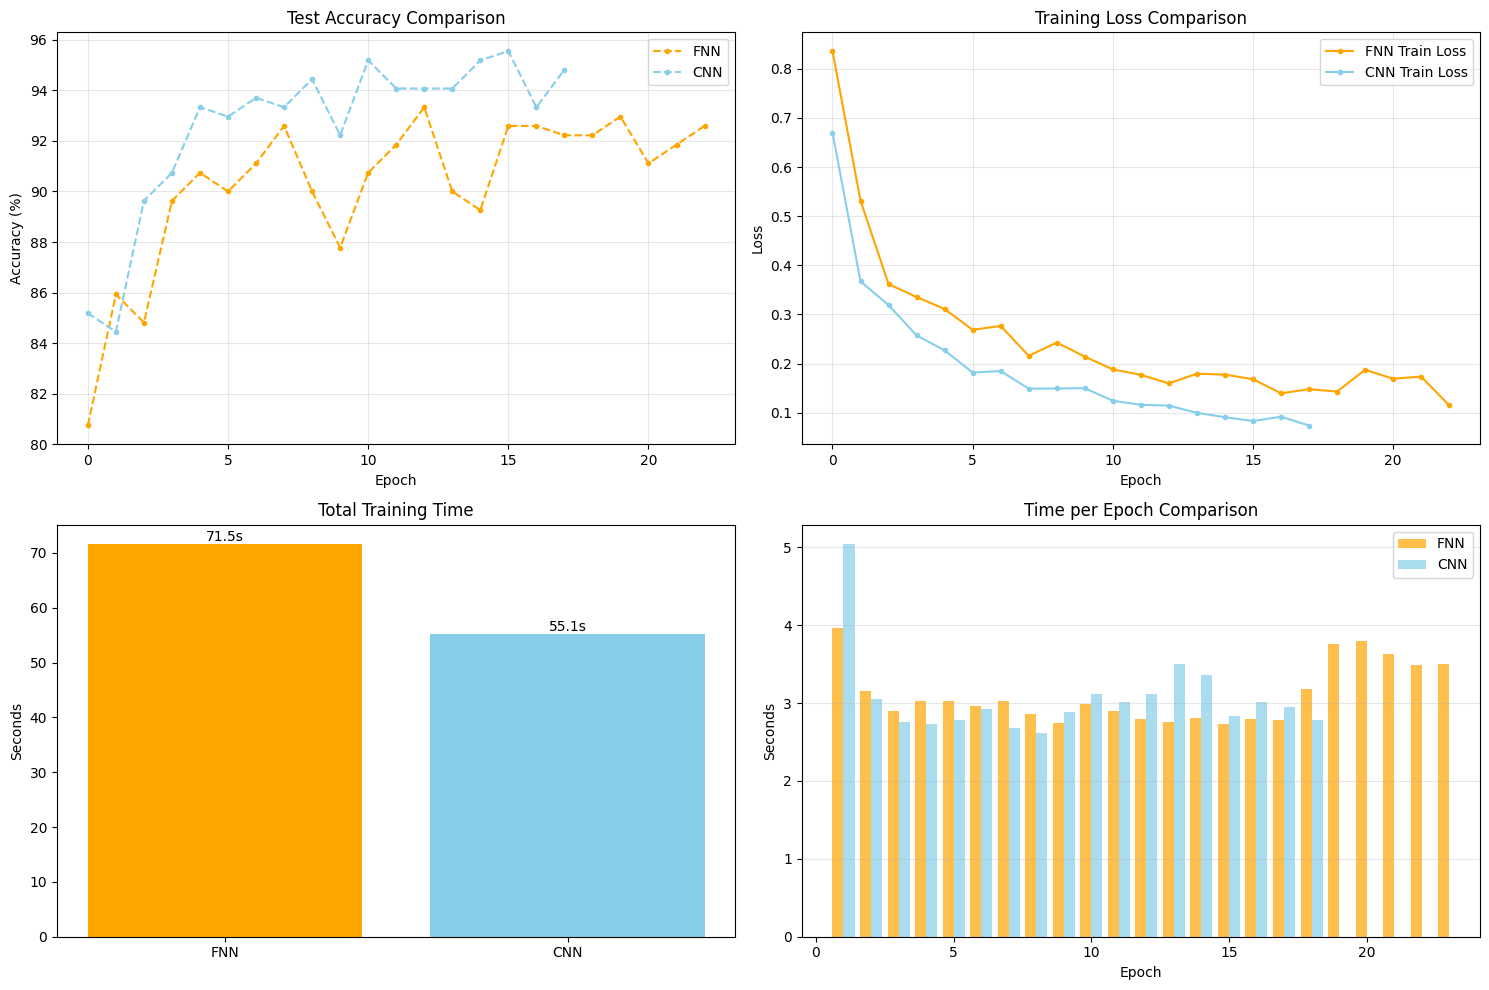

In [7]:
plot_comparison([fnn_history, cnn_history])